# projects open sourced: 小车巡线

## D-Robotics

* https://github.com/D-Robotics/line_follower
* 深度学习，通过目标点识别解决；
    * D-Robotics 丰富的教学资料： https://www.originbot.org/application/deeplearning_line_follower.html
* 视觉巡线（OpenCV）
    * https://www.originbot.org/application/cv_line_follower.html ， 但无源代码

## wheeltec

* 见其源代码包；simple_follower_ros2

## 长江大学极客班/ROS_Line_Follower

* https://gitee.com/changjiang-university_2/Line_Follower

* 文档详细，cpp实现；可以参考其中pid设置；

## a python lib for ros2

* https://github.com/gabrielnhn/ros2-line-follower/tree/main
* 基于contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 实现。

## SMARTmBOT

* https://github.com/SMARTlab-Purdue/SMARTmBOT
* Purdue 大学4年前发布；其中巡线部分可能是基于红外传感器（地面黑线白底，红外传感对黑线和白线感受到信息的反射强度不一样；）
* SPI ADC 传感器：当传感器位于白色地面时，反射光强 → 传感器输出的模拟信号值较高（代码中 spi_left/spi_right > 阈值）。当传感器位于黑色线路时，反射光弱 → 信号值较低（< 阈值）。

## jetracer

* https://github.com/NVIDIA-AI-IOT/jetracer
* 6 years ago

In [5]:
# 示例用法
image_path = "/mnt/d/wps/公司项目/宴志威/清洗机器人/images/6.png"
image_path = "/mnt/d/wps/公司项目/宴志威/清洗机器人/images/5.jpg"
image_path = "/mnt/d/code/slam/clean_robot/turn_on_wheeltec_robot/image/image_20250727_20331753619623_draw1.jpg"
# image_path = "/mnt/d/code/slam/clean_robot/turn_on_wheeltec_robot/image/image_20250525_21181748179086.jpg"

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches

# read image
image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

lsd = cv2.createLineSegmentDetector(0)
lines = lsd.detect(gray)[0]
drawn_img = lsd.drawSegments(image, lines)

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches


def horizon_angle(line):
    x1, y1, x2, y2 = line[0].astype(int)
    # 计算线段长度
    # length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    # 计算线段角度
    angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
    return angle


# 垂直角度
def vertical_angle(line):
    x1, y1, x2, y2 = line[0].astype(int)
    # 计算线段长度
    # length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    # 计算线段角度
    angle = np.degrees(np.arctan2(x2 - x1, y2 - y1))
    return angle


# 定义过滤函数
def filter_lines(lines, min_length=150, angle_threshold=30):
    filtered_lines = []
    length_list = []
    angle_list = []
    for line in lines:
        x1, y1, x2, y2 = line[0].astype(int)
        # 计算线段长度
        length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        
        if length >= min_length:
            # 计算线段角度
            h_angle = horizon_angle(line)
            v_angle = vertical_angle(line)
            # 这里简单假设角度接近水平或垂直的为直线
            if 60 < abs(v_angle) < angle_threshold:
                print(f"length={length}, h_angle={h_angle}, v_angle={v_angle}")
                filtered_lines.append(line)
                angle_list.append((h_angle, v_angle))
                length_list.append(length)
                
    return np.array(filtered_lines), angle_list, length_list


# find the longest line
def find_longest(length_list, top_k=5):
    sorted_indices = np.argsort(length_list)[-top_k:]
    return sorted_indices

# read image
image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

lsd = cv2.createLineSegmentDetector(0)
lines = lsd.detect(gray)[0]

lines, angle_list, length_list = filter_lines(lines, min_length=200, angle_threshold=70)

longest_indices = find_longest(length_list, top_k=1350)

lines = lines[longest_indices]

# if lines is not None:
#     # 过滤线段
#     filtered_lines = filter_lines(lines)
#     drawn_img = lsd.drawSegments(image, filtered_lines)
# else:
#     drawn_img = image

if lines is not None:
    # 过滤线段
    # filtered_lines = filter_lines(lines)
    # 创建图像副本，避免修改原始图像
    drawn_img = image.copy()
    # 遍历过滤后的线段，用红色绘制
    for line in lines:
        x1, y1, x2, y2 = line[0].astype(int)
        # 使用 cv2.line 绘制红色线段，颜色格式为 BGR
        cv2.line(drawn_img, (x1, y1), (x2, y2), (0, 255, 255), 2)
else:
    drawn_img = image
    

0


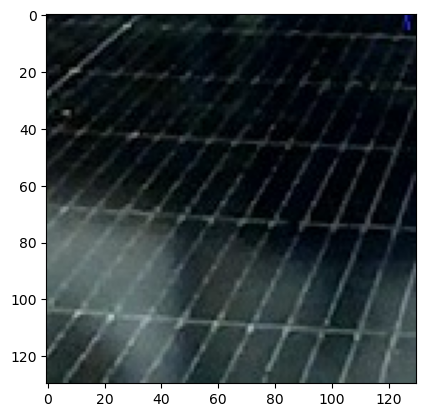

In [8]:
# plot image
print(len(lines))
plt.imshow(drawn_img)

/tmp/ipykernel_2312029/702955963.py:62: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2312029/702955963.py:62: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2312029/702955963.py:62: UserWarning: Glyph 28784 (\N{CJK UNIFIED IDEOGRAPH-7070}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2312029/702955963.py:62: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2312029/702955963.py:62: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2312029/702955963.py:62: UserWarning: Glyph 22788 (\N{CJK UNIFIED IDEOGRAPH-5904}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2312029/702955963.py:62: UserWarning: Glyph 29702 (\N{CJK UNIFIED I

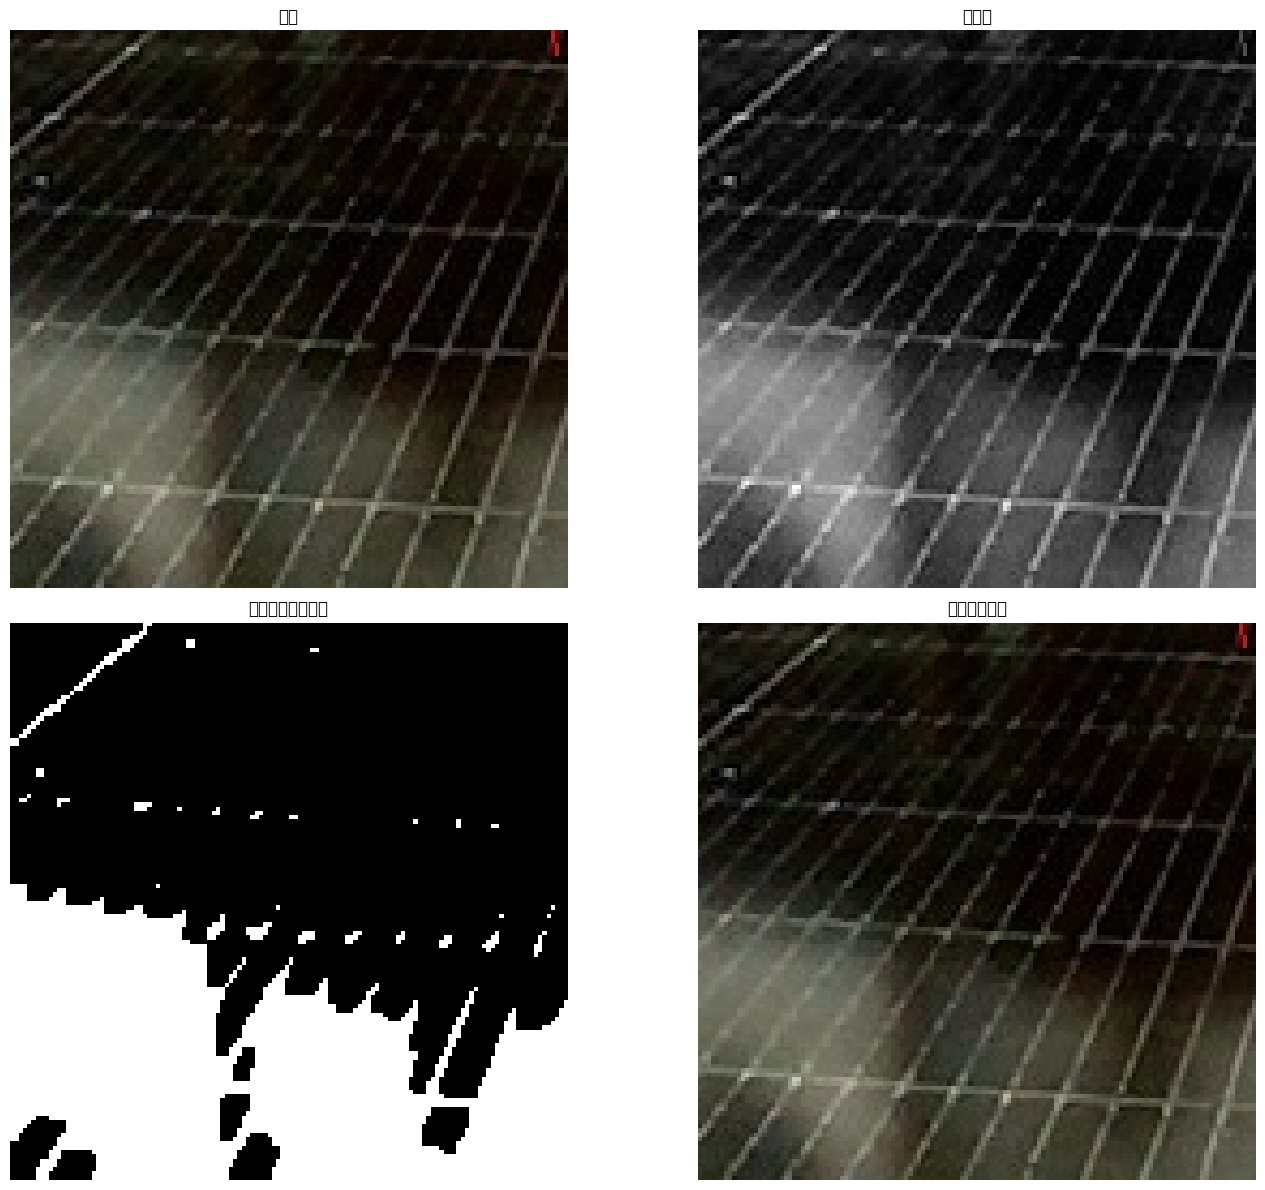

In [3]:
import cv2
import numpy as np

import matplotlib.pyplot as plt

image_path = "/mnt/d/code/slam/clean_robot/turn_on_wheeltec_robot/image/image_20250727_20331753619623_draw1.jpg"

image = cv2.imread(image_path)
# 原图（BGR转RGB用于matplotlib显示）
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 灰度图
gray = cv2.cvtColor(image_rgb, cv2.COLOR_BGR2GRAY)

# 预处理：去噪 + 二值化 + 形态学
gray_blur = cv2.GaussianBlur(gray, (3, 3), 0)
_, binary = cv2.threshold(gray_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
binary_closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

# LSD检测
lsd = cv2.createLineSegmentDetector(0)
lines = lsd.detect(binary_closed)[0]

# 后处理：过滤短线段、筛选角度
filtered_lines = []
if lines is not None:
    min_length = 50
    angle_tol = 5
    for line in lines:
        x1, y1, x2, y2 = line[0]
        length = np.linalg.norm((x2 - x1, y2 - y1))
        angle = np.abs(np.degrees(np.arctan2(y2 - y1, x2 - x1)))
        if length > min_length and ((angle < angle_tol) or (angle > 90 - angle_tol)):
            filtered_lines.append(line)

# 创建线段检测结果图像
lines_image = image_rgb.copy()
if filtered_lines:
    for line in filtered_lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(lines_image, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)

# 可视化对比
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
axs[0, 0].imshow(image_rgb)
axs[0, 0].set_title('原图')
axs[0, 0].axis('off')

axs[0, 1].imshow(gray, cmap='gray')
axs[0, 1].set_title('灰度图')
axs[0, 1].axis('off')

axs[1, 0].imshow(binary_closed, cmap='gray')
axs[1, 0].set_title('预处理后的二值图')
axs[1, 0].axis('off')

axs[1, 1].imshow(lines_image)
axs[1, 1].set_title('线段检测结果')
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Fon

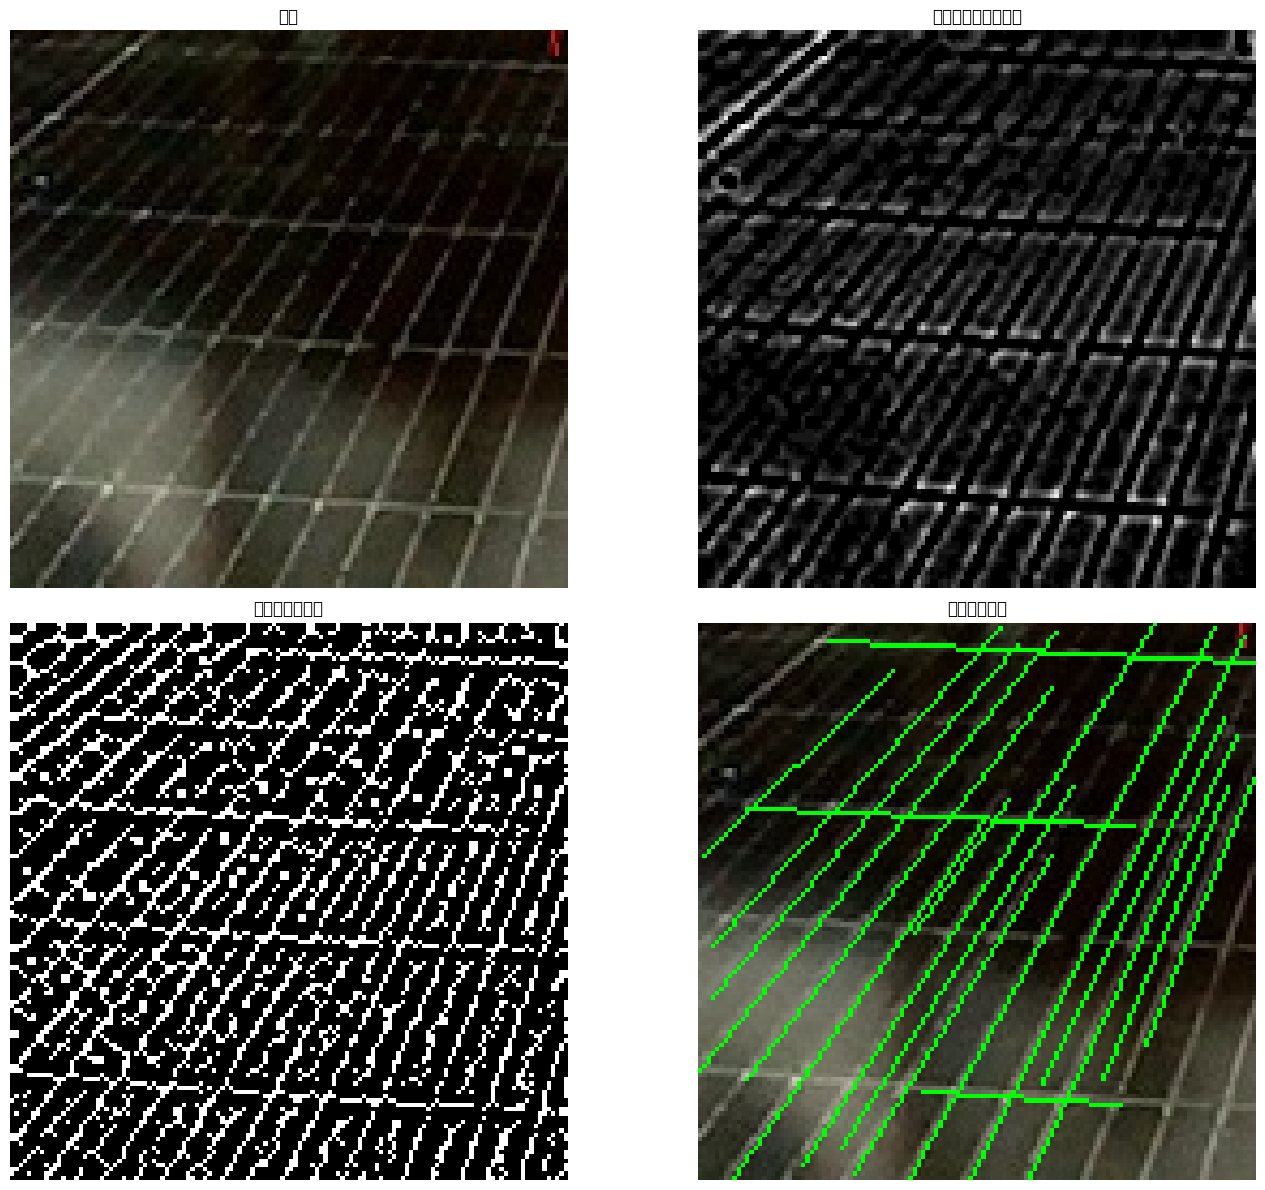

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 设置matplotlib中文字体
plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC"]

# 读取图像
image = cv2.imread(image_path)
if image is None:
    print("无法读取图像，请检查路径")
    exit()

# 原图（BGR转RGB用于matplotlib显示）
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 灰度图
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 多尺度高斯差分（DoG）增强细线
def enhance_thin_lines(gray, ksize1=3, ksize2=9, sigma1=0, sigma2=0):
    blur1 = cv2.GaussianBlur(gray, (ksize1, ksize1), sigma1)
    blur2 = cv2.GaussianBlur(gray, (ksize2, ksize2), sigma2)
    dog = cv2.subtract(blur2, blur1)  # 注意顺序：大核-小核
    # 归一化到0-255
    dog = cv2.normalize(dog, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    return dog

enhanced = enhance_thin_lines(gray)

# 自适应阈值（对光照不均更鲁棒）
binary = cv2.adaptiveThreshold(
    enhanced, 255, 
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,  # 高斯加权局部阈值
    cv2.THRESH_BINARY_INV,  # 反转二值化（线为白色）
    blockSize=15,  # 局部区域大小
    C=2  # 从均值中减去的常数
)

# 形态学操作：移除噪点并细化线条
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)  # 开运算移除小噪点

# 可选：骨架化进一步细化线条
def skeletonize(binary):
    size = np.size(binary)
    skel = np.zeros(binary.shape, np.uint8)
    element = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
    done = False
    while not done:
        eroded = cv2.erode(binary, element)
        temp = cv2.dilate(eroded, element)
        temp = cv2.subtract(binary, temp)
        skel = cv2.bitwise_or(skel, temp)
        binary = eroded.copy()
        zeros = size - cv2.countNonZero(binary)
        if zeros == size:
            done = True
    return skel

# 骨架化（可选，进一步细化线条）
skeleton = skeletonize(binary)

# 使用概率Hough变换检测线段（更适合细线）
lines = cv2.HoughLinesP(
    skeleton,  # 使用骨架化图像
    rho=1,             # 距离分辨率（像素）
    theta=np.pi/180,   # 角度分辨率（弧度）
    threshold=50,      # 最小投票数（线段长度）
    minLineLength=30,  # 最小线段长度
    maxLineGap=5       # 最大线段间隙
)

# 创建线段检测结果图像
lines_image = image_rgb.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(lines_image, (x1, y1), (x2, y2), (0, 255, 0), 1)

# 可视化对比
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
axs[0, 0].imshow(image_rgb)
axs[0, 0].set_title('原图')
axs[0, 0].axis('off')

axs[0, 1].imshow(enhanced, cmap='gray')
axs[0, 1].set_title('多尺度高斯差分增强')
axs[0, 1].axis('off')

axs[1, 0].imshow(skeleton, cmap='gray')
axs[1, 0].set_title('骨架化后的细线')
axs[1, 0].axis('off')

axs[1, 1].imshow(lines_image)
axs[1, 1].set_title('线段检测结果')
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

In [1]:
import cv2
import numpy as np

import logging
import matplotlib as mpl

# 设置 Matplotlib 日志级别为 ERROR，只显示错误信息
mpl_logger = logging.getLogger('matplotlib.font_manager')
mpl_logger.setLevel(logging.ERROR)

import matplotlib.pyplot as plt

import sys

sys.path.append("/mnt/d/code/image/mlsd_pytorch/")

from demo import LineDetector, crop, filter_lines, filter_overlapping_lines, merge_adjacent_lines, find_top_lines

class SolarPanelLineDetector:
    """光伏板银色线条检测类，支持输入图像路径或已读取的OpenCV图像"""
    
    def __init__(self, 
                 dog_ksize1=3, dog_ksize2=9,  # 多尺度高斯差分参数
                 adaptive_block_size=15, adaptive_C=2,  # 自适应阈值参数
                 morph_kernel_size=(2, 2),  # 形态学操作核大小
                 hough_threshold=50, hough_min_line_length=30, hough_max_line_gap=5):  # Hough变换参数
        # 设置matplotlib中文字体
        plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC"]
        
        # 算法参数
        self.dog_ksize1 = dog_ksize1
        self.dog_ksize2 = dog_ksize2
        self.adaptive_block_size = adaptive_block_size
        self.adaptive_C = adaptive_C
        self.morph_kernel_size = morph_kernel_size
        self.hough_threshold = hough_threshold
        self.hough_min_line_length = hough_min_line_length
        self.hough_max_line_gap = hough_max_line_gap
        
        # 处理结果
        self.original_image = None
        self.enhanced_image = None
        self.binary_image = None
        self.skeleton_image = None
        self.lines = None
        
    def load_image(self, image_input):
        """加载图像，支持图像路径或已读取的OpenCV图像"""
        if isinstance(image_input, str):
            # 从路径读取图像
            self.original_image = cv2.imread(image_input)
            if self.original_image is None:
                raise ValueError(f"无法读取图像: {image_input}")
        elif isinstance(image_input, np.ndarray):
            # 直接使用已读取的图像
            self.original_image = image_input
        else:
            raise TypeError("输入必须是图像路径(str)或OpenCV图像(np.ndarray)")
            
        # 原图（BGR转RGB用于matplotlib显示）
        self.original_image_rgb = cv2.cvtColor(self.original_image, cv2.COLOR_BGR2RGB)
        # 灰度图
        self.gray_image = cv2.cvtColor(self.original_image, cv2.COLOR_BGR2GRAY)
        return self
        
    def enhance_thin_lines(self, gray):
        """多尺度高斯差分（DoG）增强细线"""
        blur1 = cv2.GaussianBlur(gray, (self.dog_ksize1, self.dog_ksize1), 0)
        blur2 = cv2.GaussianBlur(gray, (self.dog_ksize2, self.dog_ksize2), 0)
        dog = cv2.subtract(blur2, blur1)  # 注意顺序：大核-小核
        # 归一化到0-255
        dog = cv2.normalize(dog, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
        return dog
        
    def skeletonize(self, binary):
        """骨架化算法，将线条细化为单像素宽度"""
        size = np.size(binary)
        skel = np.zeros(binary.shape, np.uint8)
        element = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
        done = False
        while not done:
            eroded = cv2.erode(binary, element)
            temp = cv2.dilate(eroded, element)
            temp = cv2.subtract(binary, temp)
            skel = cv2.bitwise_or(skel, temp)
            binary = eroded.copy()
            zeros = size - cv2.countNonZero(binary)
            if zeros == size:
                done = True
        return skel
        
    def process(self):
        """执行完整的线条检测流程"""
        if self.gray_image is None:
            raise ValueError("请先调用load_image()加载图像")
            
        # 1. 多尺度高斯差分增强细线
        self.enhanced_image = self.enhance_thin_lines(self.gray_image)
        
        # 2. 自适应阈值（对光照不均更鲁棒）
        self.binary_image = cv2.adaptiveThreshold(
            self.enhanced_image, 255, 
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,  # 高斯加权局部阈值
            cv2.THRESH_BINARY_INV,  # 反转二值化（线为白色）
            self.adaptive_block_size,  # 局部区域大小
            self.adaptive_C  # 从均值中减去的常数
        )
        
        # 3. 形态学操作：移除噪点
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, self.morph_kernel_size)
        self.binary_image = cv2.morphologyEx(self.binary_image, cv2.MORPH_OPEN, kernel, iterations=1)
        
        # 4. 骨架化进一步细化线条
        self.skeleton_image = self.skeletonize(self.binary_image)
        
        # 5. 使用概率Hough变换检测线段
        self.lines = cv2.HoughLinesP(
            self.skeleton_image,
            rho=1,                   # 距离分辨率（像素）
            theta=np.pi/180,         # 角度分辨率（弧度）
            threshold=self.hough_threshold,  # 最小投票数（线段长度）
            minLineLength=self.hough_min_line_length,  # 最小线段长度
            maxLineGap=self.hough_max_line_gap  # 最大线段间隙
        )
        
        return self
        
    def visualize(self):
        """可视化处理过程和结果"""
        if self.lines is None:
            raise ValueError("请先调用process()处理图像")
            
        # 创建线段检测结果图像
        lines_image = self.original_image_rgb.copy()
        if self.lines is not None:
            for line in self.lines:
                x1, y1, x2, y2 = line[0]
                cv2.line(lines_image, (x1, y1), (x2, y2), (0, 255, 0), 1)
        
        # 可视化对比
        fig, axs = plt.subplots(2, 2, figsize=(15, 12))
        axs[0, 0].imshow(self.original_image_rgb)
        axs[0, 0].set_title('origin image')
        axs[0, 0].axis('off')
        
        axs[0, 1].imshow(self.enhanced_image, cmap='gray')
        axs[0, 1].set_title('enhanced image')
        axs[0, 1].axis('off')
        
        axs[1, 0].imshow(self.skeleton_image, cmap='gray')
        axs[1, 0].set_title('skeleton_image')
        axs[1, 0].axis('off')
        
        axs[1, 1].imshow(lines_image)
        axs[1, 1].set_title('lines_image')
        axs[1, 1].axis('off')
        
        plt.tight_layout()
        plt.show()
        
    def get_lines(self):
        """返回检测到的线段"""
        if self.lines is None:
            raise ValueError("请先调用process()处理图像")
        return self.lines


-72.10812287080176
55.045330369496696
51.1886159632416
50.12819104185286
58.877529803208006
57.150911040914195
52.125016348901795
-72.03086025984294
53.94538183353893
55.76814456110782
57.994616791916485
59.67639313745002
48.91824886406738
63.97040780848653
63.853158764419106
60.802513953935545
46.24536426676832
62.10272896905235
54.63753811293094
61.927513064147035
45.658543177563615
43.2642954110716
50.47736872882888
-16.38954033403479
59.99507912917602
49.51398845800128
52.27500495788928
46.46880071438585
-82.05652818940962
-73.07248693585296
55.7842978675626
57.26477372789242
83.08877288097528
54.72757855140162
filter_lines lines: 29
filter_overlapping_lines lines: (14, 4)
merge_adjacent_lines lines: (14, 4)


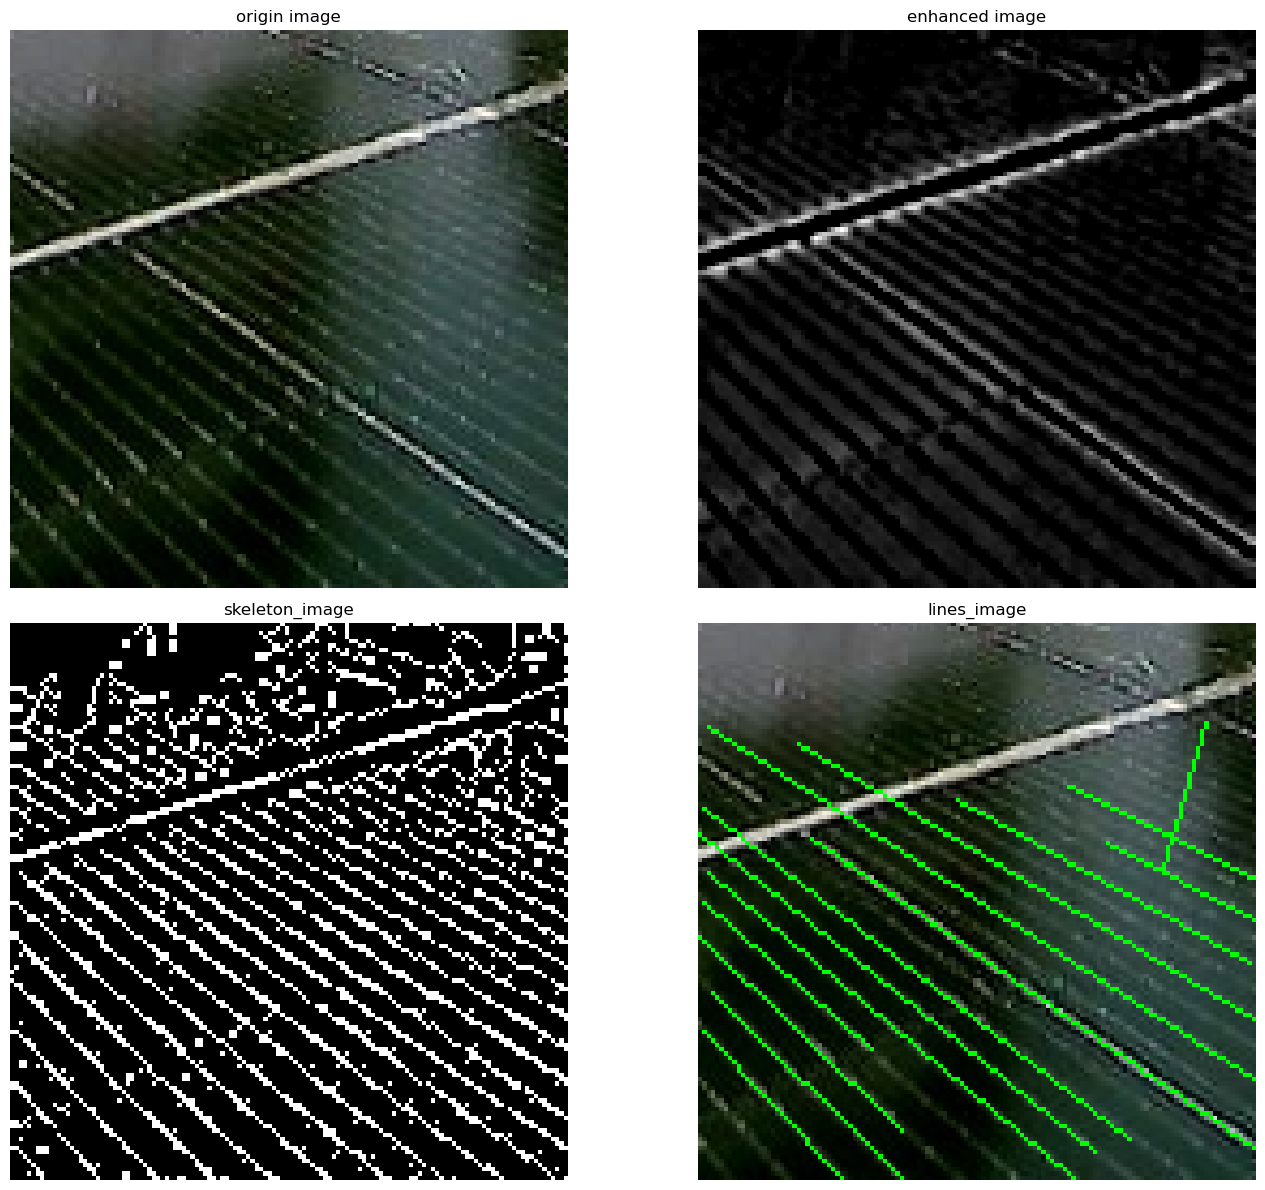

In [25]:
# 使用示例
# 方法1：通过图像路径初始化并处理
# image_path = "/mnt/d/code/slam/clean_robot/turn_on_wheeltec_robot/image/image_20250727_20331753619623_draw1.jpg"
image_path = "/mnt/d/code/slam/clean_robot/turn_on_wheeltec_robot/image/image_20250728_00531753635191.jpg"
image_path = "/mnt/d/code/slam/clean_robot/turn_on_wheeltec_robot/image/image_20250728_00391753634377.jpg"
detector = SolarPanelLineDetector(
    dog_ksize1=3, dog_ksize2=15,  # 调整参数增强细线
    hough_threshold=25,           # 降低阈值检测更短线段
    adaptive_block_size=13, adaptive_C=3,  # 自适应阈值参数
    morph_kernel_size=(2, 2),  # 形态学操作核大小
    hough_min_line_length=30, hough_max_line_gap=5
)
img = cv2.imread(image_path)

img = crop(img)

detector.load_image(img)
detector.process()
lines = detector.get_lines()



# lines = detector.detect(img)

top_lines, angles = find_top_lines(np.squeeze(lines), top_k=20)

detector.lines = np.expand_dims(top_lines, 1)

detector.visualize()


# 方法2：直接传入已读取的图像
# img = cv2.imread(image_path)
# detector = SolarPanelLineDetector(
#     dog_ksize1=3, dog_ksize2=11,  # 调整参数增强细线
#     hough_threshold=40,           # 降低阈值检测更短线段
# )
# detector.load_image(img)
# detector.process()
# lines = detector.get_lines()
# print(f"检测到 {len(lines)} 条线段")

In [21]:
py_path = "/mnt/d/code/image/mlsd_pytorch/"

import sys

sys.path.append(py_path)

In [5]:
len(lines)

24

In [8]:
f_lines, angles = find_top_lines(np.squeeze(lines))

-82.81946450227986
-83.31613589196587
-78.94854297333455
-83.15722658736905
-82.64762064010762
-82.05652818940962
-80.77011375627228
-83.31613589196587
-78.95905981967627
-79.89070150750479
-80.69794528870119
-81.1870983622556
-81.1870983622556
-82.01067323360309
-82.8749836510982
-84.01940047523652
-79.18612248637504
-79.24903300681194
-78.91743053697036
-77.47119229084848
-78.9964591482505
-84.06847307508025
-81.63411387596739
90
-80.77011375627228
filter_lines lines: 0
filter_overlapping_lines lines: (0,)
merge_adjacent_lines lines: (0,)


tuple

In [19]:


detector.lines = np.expand_dims(f_lines, 1)


findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Fon

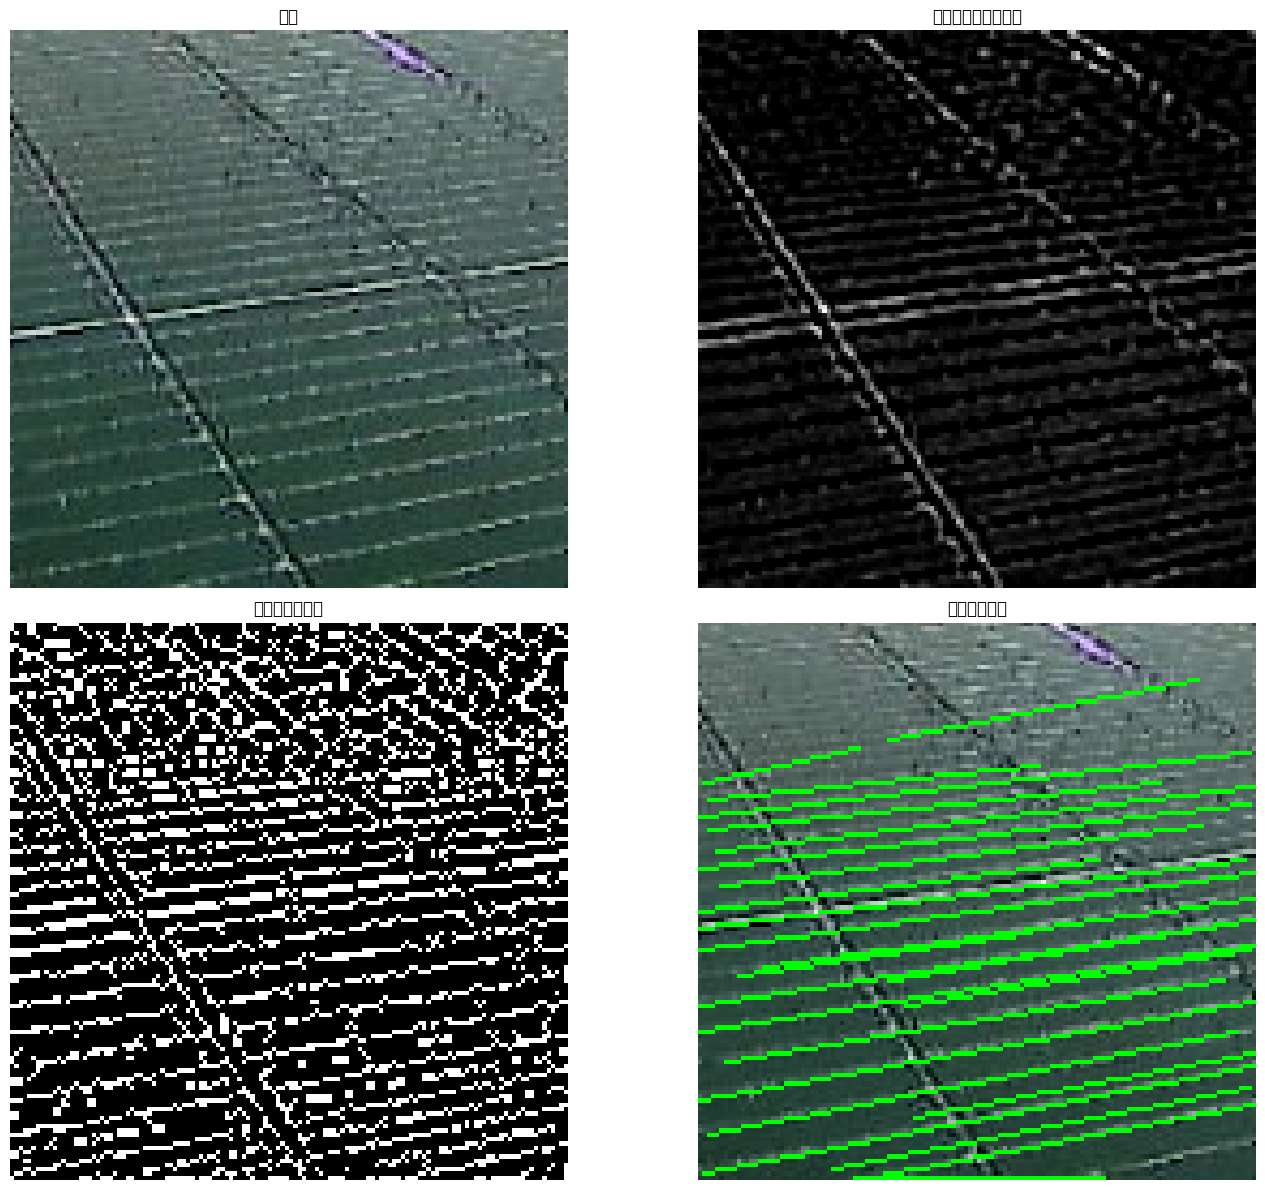

In [9]:
detector.visualize()
